In [1]:
!pip install pandas numpy matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [6]:
trades = pd.read_csv("/content/historical_data.csv")
sentiment = pd.read_csv("/content/fear_greed_index.csv")

In [7]:
#Viewing first rows
print("TRADES DATA")
display(trades.head())

print("SENTIMENT DATA")
display(sentiment.head())

TRADES DATA


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


SENTIMENT DATA


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
#Checking Dataset shapes
print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


In [9]:
#Checing Column Names
print("Trades Columns:")
print(trades.columns)

print("\nSentiment Columns:")
print(sentiment.columns)

Trades Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Sentiment Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [10]:
#Checking Missing Values
print("Trades Missing Values")
print(trades.isnull().sum())

print("\nSentiment Missing Values")
print(sentiment.isnull().sum())

Trades Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [15]:
#Converting Dates
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])
trades['Date'] = trades['Timestamp'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date'].dt.date

In [16]:
#Merging Datasets
merged = pd.merge(
    trades,
    sentiment,
    on='Date',
    how='left'
)

print("Merged Shape:", merged.shape)

display(merged.head())

Merged Shape: (211224, 21)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01,NaN,NaN,NaN,NaT
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01,NaN,NaN,NaN,NaT
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01,NaN,NaN,NaN,NaT
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01,NaN,NaN,NaN,NaT
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01,NaN,NaN,NaN,NaT


In [19]:
#Analysing Profit Loss Sentiment
profit_by_sentiment = merged.groupby(
    'classification'
)['Closed PnL'].agg(['count','mean','sum'])

display(profit_by_sentiment)


,count,mean,sum
classification,,,


In [21]:
print(merged.shape)
print(merged.head())
print(merged['classification'].value_counts(dropna=False))

(211224, 21)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  520

In [24]:
print(trades.columns.tolist())
print(sentiment.columns.tolist())
print(trades['Timestamp IST'].head())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date']
['timestamp', 'value', 'classification', 'date', 'Date']
0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object


In [25]:
# Check sentiment dates

print(sentiment[['date','classification']].head())
print(sentiment[['date','classification']].tail())

        date classification
0 2018-02-01           Fear
1 2018-02-02   Extreme Fear
2 2018-02-03           Fear
3 2018-02-04   Extreme Fear
4 2018-02-05   Extreme Fear
           date classification
2639 2025-04-28        Neutral
2640 2025-04-29          Greed
2641 2025-04-30          Greed
2642 2025-05-01        Neutral
2643 2025-05-02          Greed


In [26]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['trade_date'] = trades['Timestamp IST'].dt.date

print(trades[['Timestamp IST','trade_date']].head())

        Timestamp IST  trade_date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02


In [28]:
# Convert trader date to datetime
trades['trade_date'] = pd.to_datetime(trades['trade_date'])

# Convert sentiment date to datetime
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Verify
print(trades['trade_date'].dtype)
print(sentiment['date'].dtype)

datetime64[ns]
datetime64[ns]


In [29]:
merged = pd.merge(
    trades,
    sentiment,
    left_on='trade_date',
    right_on='date',
    how='left'
)

print("Rows:", len(merged))
print("\nClassification counts:")
print(merged['classification'].value_counts(dropna=False))

Rows: 211224

Classification counts:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64


In [30]:
merged[['trade_date','classification']].head(20)

,trade_date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed
5,2024-12-02,Extreme Greed
6,2024-12-02,Extreme Greed
7,2024-12-02,Extreme Greed
8,2024-12-02,Extreme Greed
9,2024-12-02,Extreme Greed


In [31]:
#Profitability by Sentinment
profit_by_sentiment = merged.groupby(
    'classification'
)['Closed PnL'].agg(
    ['count', 'mean', 'sum']
)

display(profit_by_sentiment)

,count,mean,sum
classification,,,
Extreme Fear,21400,34.537862,7.391102e+05
Extreme Greed,39992,67.892861,2.715171e+06
Fear,61837,54.290400,3.357155e+06
Greed,50303,42.743559,2.150129e+06
Neutral,37686,34.307718,1.292921e+06


In [33]:
#Win Rate Analaysis
merged['win'] = (merged['Closed PnL'] > 0).astype(int)

win_rate = merged.groupby(
    'classification'
)['win'].mean() * 100

display(win_rate)

,win
classification,
Extreme Fear,37.060748
Extreme Greed,46.494299
Fear,42.076750
Greed,38.482794
Neutral,39.699093


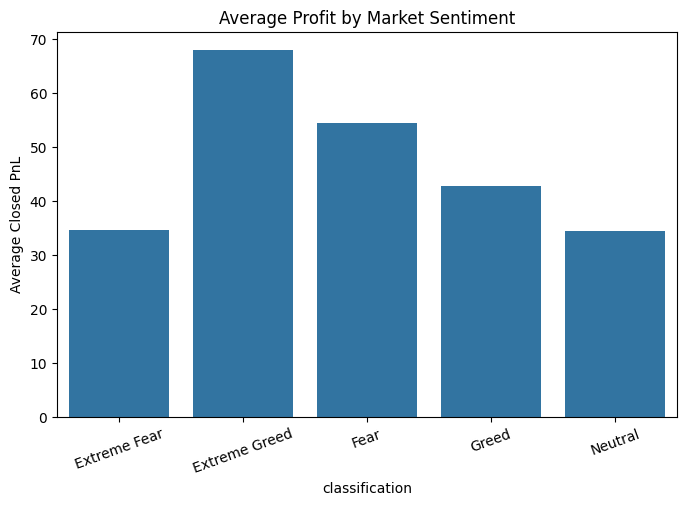

In [34]:
# VISUALIZATION : AVG PNL
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x=profit_by_sentiment.index,
    y=profit_by_sentiment['mean']
)

plt.title('Average Profit by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.xticks(rotation=20)

plt.show()

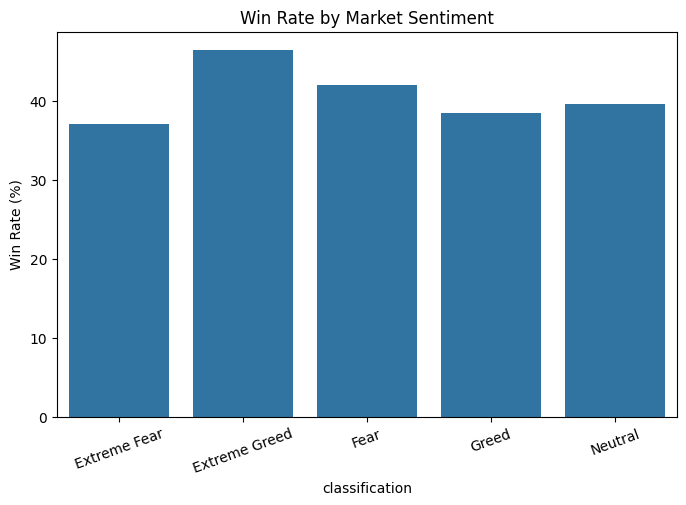

In [35]:
# VISUALIZATION: WIN RATE
plt.figure(figsize=(8,5))

sns.barplot(
    x=win_rate.index,
    y=win_rate.values
)

plt.title('Win Rate by Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.xticks(rotation=20)

plt.show()

In [39]:
for col in merged.columns:
    print(col)

Account
Coin
Execution Price
Size Tokens
Size USD
Side
Timestamp IST
Start Position
Direction
Closed PnL
Transaction Hash
Order ID
Crossed
Fee
Trade ID
Timestamp
Date_x
trade_date
timestamp
value
classification
date
Date_y
win


In [40]:
# Buy VS Sell Activity
side_analysis = pd.crosstab(
    merged['classification'],
    merged['Side']
)

display(side_analysis)

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


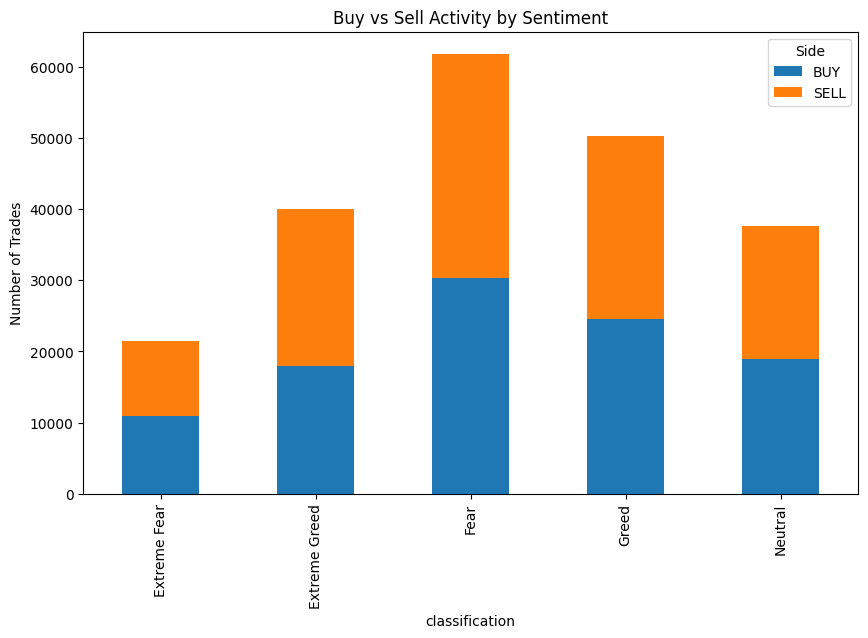

In [41]:
side_analysis.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Buy vs Sell Activity by Sentiment")
plt.ylabel("Number of Trades")
plt.show()

In [42]:
#Most Profitabe Coins
coin_profit = merged.groupby(
    'Coin'
)['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

display(coin_profit)

,Closed PnL
Coin,
@107,2.783913e+06
HYPE,1.948485e+06
SOL,1.639556e+06
ETH,1.319979e+06
BTC,8.680447e+05
MELANIA,3.903511e+05
ENA,2.173295e+05
SUI,1.992688e+05
ZRO,1.837778e+05


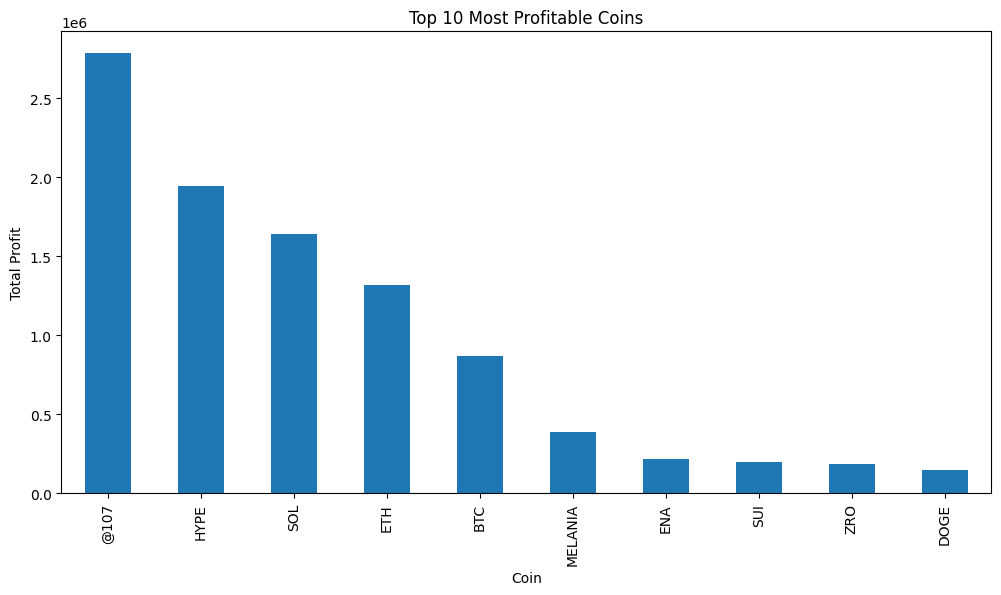

In [43]:
plt.figure(figsize=(12,6))

coin_profit.plot(kind='bar')

plt.title("Top 10 Most Profitable Coins")
plt.ylabel("Total Profit")
plt.show()

In [44]:
# Top Traders
top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

display(top_traders)

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05


In [45]:
# Fees vs Profit
fee_analysis = merged.groupby(
    'classification'
)[['Fee','Closed PnL']].mean()

display(fee_analysis)

,Fee,Closed PnL
classification,,
Extreme Fear,1.116291,34.537862
Extreme Greed,0.675902,67.892861
Fear,1.495172,54.290400
Greed,1.254372,42.743559
Neutral,1.044798,34.307718


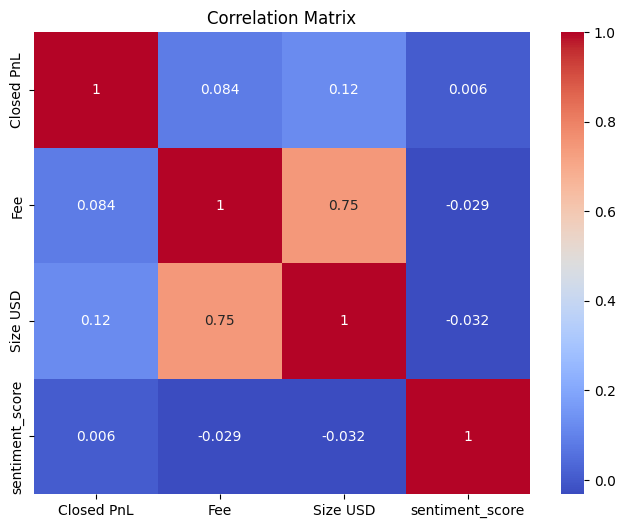

In [47]:
# Correlation Heatmap
mapping = {
    'Extreme Fear':1,
    'Fear':2,
    'Neutral':3,
    'Greed':4,
    'Extreme Greed':5
}

merged['sentiment_score'] = merged[
    'classification'
].map(mapping)
corr = merged[
    ['Closed PnL','Fee','Size USD','sentiment_score']
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()